<font color="#0D47A1" size="6">
<b>Análise dos Fatores que Influenciam o Valor dos Aluguéis</b>
</font>



<font color="#1565C0" size="5">
<b>1. Problema de Negócio</b>
</font>:


Uma imobiliária deseja compreender quais características dos imóveis exercem maior influência sobre o valor dos aluguéis, auxiliando processos de precificação e tomada de decisão.


<font color="#1565C0" size="5">
<b>2. Público Alvo</b>
</font>:

Os resultados desta análise podem auxiliar:

- Imobiliárias na definição de estratégias de precificação;
- Corretores de imóveis na avaliação de propriedades;
- Proprietários na definição de valores de locação;
- Investidores na identificação de oportunidades de mercado;
- Administradoras de imóveis na gestão de portfólios;
- Potenciais locatários na comparação de imóveis e preços.



<font color="#1565C0" size="5">
<b>3. Objetivos do Projeto</b>
</font>:

Este projeto tem como objetivo identificar quais características dos imóveis possuem maior influência sobre o valor dos aluguéis utilizando técnicas de análise exploratória de dados (EDA).

Perguntas investigadas:

- A área do imóvel influencia o valor do aluguel?
- Existe relação entre quantidade de quartos e preço?
- O número de banheiros impacta o aluguel?
- Vagas de garagem aumentam o valor do imóvel?
- A aceitação de animais influencia o preço?
- Imóveis mobiliados apresentam aluguéis mais elevados?

<font color="#1565C0" size="5">
<b>4. Importação das Bibliotecas</b>
</font>





Nesta etapa são carregadas as bibliotecas necessárias para manipulação, análise e visualização dos dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('pastel')


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving houses_to_rent.csv to houses_to_rent (2).csv


<font color="#1565C0" size="5">
<b>5. Carregamento e Inspeção Inicial dos Dados</b>
</font>

Nesta etapa são importadas as bibliotecas utilizadas para manipulação, análise e visualização dos dados.

- Pandas: manipulação de dados tabulares;
- NumPy: operações numéricas;
- Matplotlib: criação de gráficos;
- Seaborn: visualizações estatísticas.

A base de dados foi carregada a partir de um arquivo CSV, obtido na plataforma Kaggle, contendo informações sobre imóveis para locação em diferentes cidades brasileiras

In [ ]:
df = pd.read_csv('houses_to_rent.csv')

In [ ]:
df.head()


,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  object
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 1.1+ MB


Observa-se que a base contém informações relacionadas às características dos imóveis, incluindo área, quantidade de quartos, banheiros, vagas de garagem, mobiliário, taxas adicionais e valor do aluguel.

<font color="#1565C0" size="5">
<b>6. Limpeza de Dados</b>
</font>

Nesta etapa são identificadas e corrigidas inconsistências presentes na base de dados, garantindo maior qualidade e confiabilidade para as análises posteriores.

<font color="#1565C0" size="4">
<b>6.1 Investigação da Variável Floor</b>
</font>

A variável `floor`, responsável por representar o andar do imóvel, apresentou registros com o caractere '-' em vez de valores numéricos.

Essa inconsistência impede a conversão da coluna para formato numérico e pode comprometer análises estatísticas futuras.

In [ ]:
df['floor'].unique()

array(['7', '20', '6', '2', '1', '-', '4', '3', '10', '11', '24', '9',
       '8', '17', '18', '5', '13', '15', '16', '14', '26', '12', '21',
       '19', '22', '27', '23', '35', '25', '46', '28', '29', '301', '51',
       '32'], dtype=object)

<font color="#1565C0" size="4">
<b>6.2 Tratamento da Variável Floor</b>
</font>

Os registros representados por '-' serão substituídos por 0 para indicar imóveis sem informação de andar, permitindo a conversão da variável para formato numérico.

In [ ]:
df['floor'] = df['floor'].replace('-', 0)
df['floor'] = df['floor'].astype(int)

<font color="#1565C0" size="4">
<b>6.3 Validação das Alterações</b>
</font>

Verificação da estrutura da base após o tratamento da variável floor.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  int64 
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.1+ MB


<font color="#1565C0" size="4">
<b>6.4 Identificação de Registros Duplicados</b>
</font>

Busca por registros repetidos que possam distorcer as análises estatísticas.

In [ ]:
df.duplicated().sum()

np.int64(358)


Visualização de exemplos dos registros identificados como duplicados para validar a necessidade de remoção.

In [ ]:
df[df.duplicated()].head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
244,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
920,Belo Horizonte,40,1,1,1,2,not acept,furnished,0,970,0,13,983
1060,São Paulo,136,3,3,3,13,acept,not furnished,1430,4206,364,54,6054
1064,São Paulo,20,1,1,0,5,acept,furnished,602,1800,130,23,2555
1108,Campinas,184,4,3,4,0,acept,not furnished,0,3240,220,49,3509


Análise detalhada de um dos registros marcados como duplicados.

In [ ]:
df.loc[244]

,244
city,Porto Alegre
area,47
rooms,1
bathroom,1
parking spaces,1
floor,1
animal,not acept
furniture,furnished
hoa (R$),400
rent amount (R$),2200


Busca por todos os registros idênticos ao imóvel selecionado para confirmar a duplicação.

In [ ]:
df[df.eq(df.loc[244]).all(axis=1)]

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
76,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
244,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
1387,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
2025,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
2114,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
3043,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
3232,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
3857,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
3904,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633
4072,Porto Alegre,47,1,1,1,1,not acept,furnished,400,2200,0,33,2633


<font color="#1565C0" size="4">
<b>6.5 Remoção dos Registros Duplicados</b>
</font>

Após a validação dos registros repetidos, os duplicados serão removidos da base.

In [ ]:
df = df.drop_duplicates()



Avaliação da quantidade final de registros após a etapa de limpeza.

In [ ]:
df.shape

(10334, 13)

<font color="#1565C0" size="4">
<b>6.6 Estatísticas Descritivas</b>
</font>

Análise das principais medidas estatísticas das variáveis numéricas, incluindo média, mediana, valores mínimos e máximos.

In [ ]:
df.describe()

,area,rooms,bathroom,parking spaces,floor,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10334.000000,10334.000000,10334.000000,10334.000000,10334.000000,1.033400e+04,10334.000000,10334.000000,10334.000000,1.033400e+04
mean,152.439423,2.539965,2.268725,1.644475,5.100929,1.091244e+03,3966.296013,376.929263,54.264273,5.488943e+03
std,545.875595,1.168185,1.414650,1.598527,6.067906,1.144609e+04,3436.190007,3160.602165,48.164380,1.266911e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,59.000000,2.000000,1.000000,1.000000,1.000000,1.800000e+02,1598.250000,41.000000,21.000000,2.116000e+03
50%,95.000000,3.000000,2.000000,1.000000,3.000000,5.710000e+02,2750.000000,130.000000,37.000000,3.685500e+03
75%,190.000000,3.000000,3.000000,2.000000,8.000000,1.286750e+03,5000.000000,389.750000,70.000000,6.912000e+03
max,46335.000000,13.000000,10.000000,12.000000,301.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


<font color="#1565C0" size="4">
<b>6.7 Conclusões da Etapa de Limpeza</b>
</font>

Após a preparação dos dados, foram observados os seguintes pontos:

- Não foram identificados valores ausentes na base de dados;
- A variável `floor` apresentava inconsistências e foi convertida para formato numérico;
- Foram removidos 358 registros duplicados, reduzindo possíveis distorções estatísticas;
- A análise descritiva indicou a presença de valores extremos em algumas variáveis, que serão investigados na próxima etapa.

Após os procedimentos de limpeza, a base foi considerada adequada para a realização da análise exploratória.

<font color="#1565C0" size="5">
<b>7. Outliers</b>
</font>

A análise descritiva revelou a presença de valores extremamente elevados em algumas variáveis, como área, condomínio e valor do aluguel.

Nesta etapa será investigado se esses registros representam observações legítimas ou possíveis inconsistências na base de dados.

<font color="#1565C0" size="4">
<b>7.1 Análise dos Maiores Valores de Área</b>
</font>


In [ ]:
df.nlargest(5, 'area')

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
2397,Belo Horizonte,46335,4,8,5,11,acept,furnished,960,8500,646,114,10220
5915,São Paulo,24606,5,4,4,12,acept,not furnished,2254,8100,7859,103,18320
9241,Campinas,12732,3,2,0,3,acept,not furnished,700,1600,96,21,2417
5129,Belo Horizonte,2000,4,2,3,0,acept,not furnished,0,4956,200,82,5238
8790,Belo Horizonte,2000,3,3,2,2,acept,furnished,3000,5000,200,67,8267


<font color="#1565C0" size="4">
<b>7.2 Análise dos Maiores Valores de Aluguel</b>
</font>

In [ ]:
df.nlargest(5, 'rent amount (R$)')

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
2182,São Paulo,700,4,7,8,0,acept,not furnished,0,45000,8750,677,54430
7748,São Paulo,350,3,3,3,0,acept,not furnished,0,30000,560,451,31010
6947,São Paulo,486,8,4,6,0,acept,not furnished,0,25000,2200,376,27580
2619,São Paulo,80,2,1,1,1,acept,not furnished,875,24000,0,305,25180
157,São Paulo,660,4,5,5,12,acept,furnished,4800,20000,1750,254,26800


Observa-se a existência de imóveis com áreas muito superiores ao padrão da base.

Embora imóveis de grande porte possam existir, valores acima de 10.000 m² serão analisados com cautela devido à sua baixa representatividade e potencial inconsistência cadastral.

<font color="#1565C0" size="4">
<b>7.3 Análise dos Maiores Valores de Condomínio</b>
</font>

In [ ]:
df.nlargest(5, 'hoa (R$)')

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
255,Belo Horizonte,155,1,4,0,4,not acept,not furnished,1117000,2790,64,38,1120000
6230,São Paulo,340,5,4,2,7,acept,not furnished,220000,12000,1000,153,233200
2859,São Paulo,285,4,5,4,6,acept,furnished,200000,20000,1834,254,222100
2928,Rio de Janeiro,35,1,1,0,1,acept,furnished,81150,4500,9900,58,95610
1444,Porto Alegre,42,1,1,0,10,acept,not furnished,32000,700,40,11,32750


Os valores de condomínio identificados são incompatíveis com as características dos imóveis registrados, sugerindo possíveis erros de cadastro ou digitação.

<font color="#1565C0" size="4">
<b>7.4 Visualização por Boxplots</b>
</font>

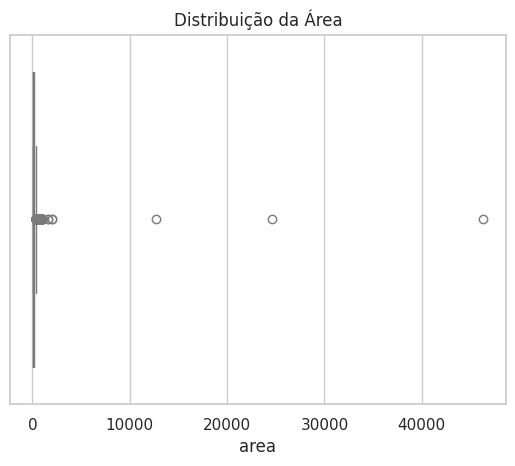

In [ ]:
plt.title('Distribuição da Área')
sns.boxplot(x=df['area'])
plt.show()

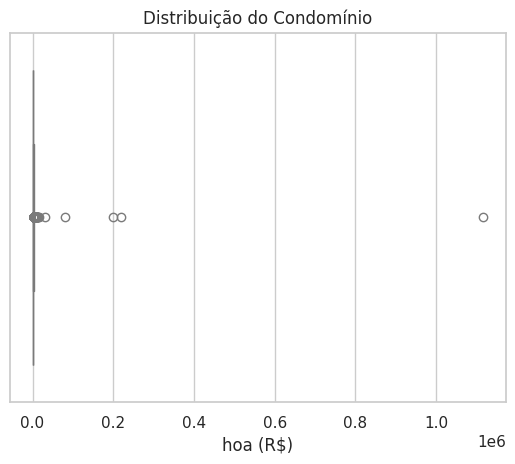

In [ ]:
plt.title('Distribuição do Condomínio')
sns.boxplot(x=df['hoa (R$)'])
plt.show()

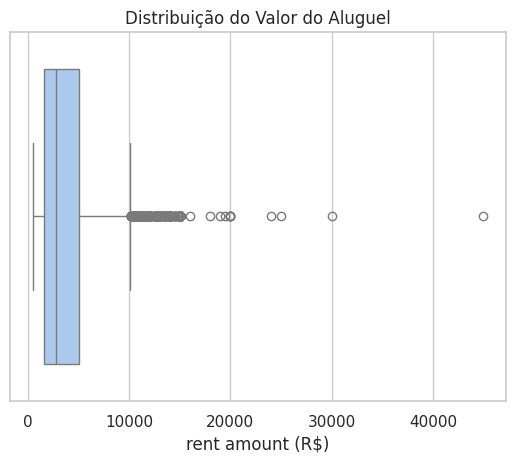

In [ ]:
plt.title('Distribuição do Valor do Aluguel')
sns.boxplot(x=df['rent amount (R$)'])
plt.show()

<font color="#1565C0" size="4">
<b>7.5 Interpretação dos Resultados</b>
</font>

Principais conclusões da análise:

- Foram identificados valores extremos nas variáveis área, condomínio e aluguel;
- A variável condomínio apresentou possíveis inconsistências cadastrais;
- Os maiores valores de aluguel mostraram-se compatíveis com imóveis de alto padrão;
- Os outliers foram avaliados individualmente antes da aplicação de qualquer tratamento;
- Apenas registros considerados inconsistentes foram selecionados para tratamento na etapa seguinte.

<font color="#1565C0" size="4">
<b>7.6
 Criação da Base Tratada</b>
</font>

Critérios adotados:

- Condomínios superiores a R$ 50.000 foram considerados inconsistentes;
- Áreas superiores a 10.000 m² foram consideradas pouco representativas para o contexto analisado.

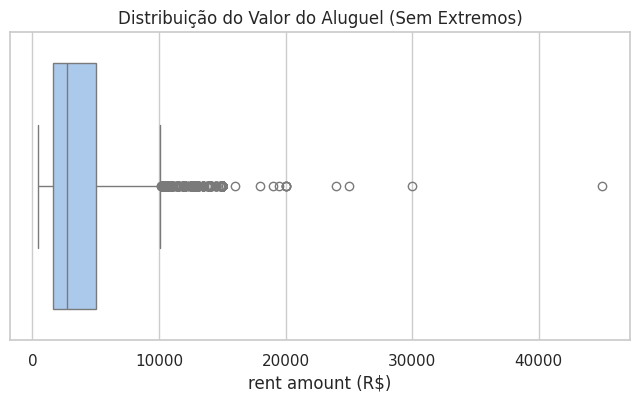

In [ ]:
# Criando uma base limpa sem os erros óbvios de cadastro (outliers extremos)
df_clean = df[df['hoa (R$)'] < 50000]        # Remove o condomínio de 1 milhão
df_clean = df_clean[df_clean['area'] < 10000] # Remove áreas fora da realidade

# Plotando o boxplot atualizado para conferir o resultado do aluguel
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['rent amount (R$)'])
plt.title('Distribuição do Valor do Aluguel (Sem Extremos)')
plt.show()

<font color="#1565C0" size="4">
<b>7.7 Conclusões da Etapa</b>
</font>

Após análise individual dos registros:

- Os maiores valores de aluguel foram mantidos por serem compatíveis com imóveis de alto padrão;
- Registros com valores excessivos de condomínio foram considerados potenciais erros de cadastro;
- Áreas extremamente elevadas foram removidas para evitar distorções estatísticas;
- Foi criada uma versão tratada da base, denominada `df_clean`, que será utilizada nas próximas análises.

<font color="#1565C0" size="5">
<b>8. Análise Exploratória</b>
</font>

<font color="#1565C0" size="4">
<b>8.1 Aluguel por Cidade</b>
</font>

Comparação dos valores médios de aluguel entre as cidades presentes na base de dados.

In [ ]:
df_clean.groupby('city')['rent amount (R$)'].mean().sort_values(ascending=False)

,rent amount (R$)
city,
São Paulo,4722.011726
Belo Horizonte,3739.141674
Rio de Janeiro,3326.190909
Campinas,2393.862530
Porto Alegre,2349.467938


/tmp/ipykernel_11230/1351296644.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=figsize_dados.values, y=figsize_dados.index, palette='Blues_d')


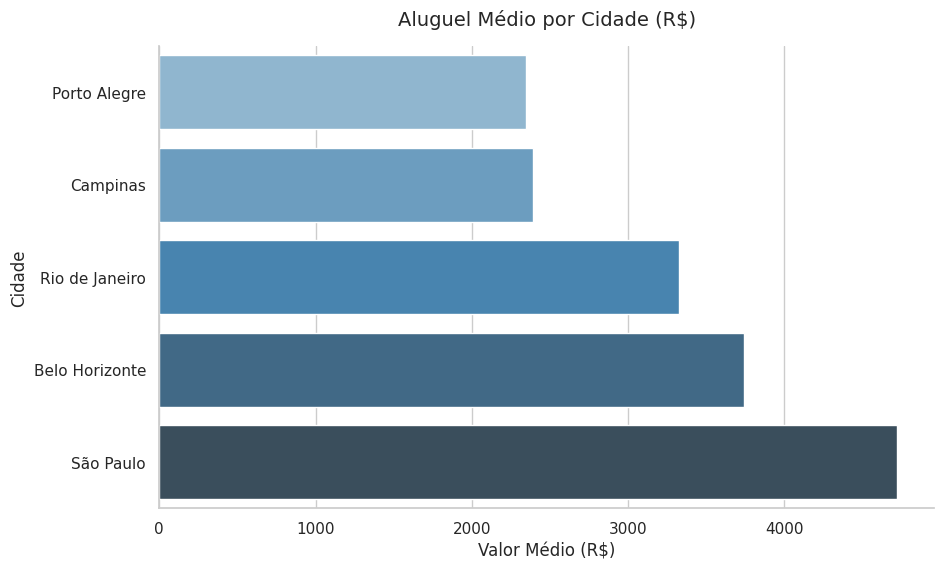

In [ ]:
plt.figure(figsize=(10, 6))

# Calculando a média usando a base limpa para não distorcer o gráfico
figsize_dados = df_clean.groupby('city')['rent amount (R$)'].mean().sort_values(ascending=True)

# Gerando um visual moderno com o Seaborn
sns.barplot(x=figsize_dados.values, y=figsize_dados.index, palette='Blues_d')

plt.title('Aluguel Médio por Cidade (R$)', fontsize=14, pad=15)
plt.xlabel('Valor Médio (R$)', fontsize=12)
plt.ylabel('Cidade', fontsize=12)
sns.despine() # Remove bordas desnecessárias do gráfico

plt.show()

In [ ]:
df_clean.groupby('city')['rent amount (R$)'].mean().sort_values(ascending=False)

,rent amount (R$)
city,
São Paulo,4722.011726
Belo Horizonte,3739.141674
Rio de Janeiro,3326.190909
Campinas,2393.862530
Porto Alegre,2349.467938


### Principais Conclusões

- São Paulo apresentou o maior aluguel médio da base;
- Belo Horizonte e Rio de Janeiro ocuparam a segunda e terceira posições;
- Campinas e Porto Alegre registraram os menores valores médios;
- A localização geográfica mostrou forte influência sobre o preço dos imóveis.


<font color="#1565C0" size="4">
<b>8.2 Área x Aluguel</b>
</font>



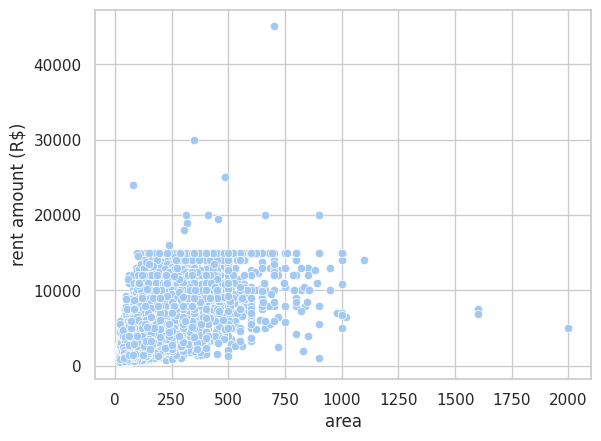

In [ ]:
sns.scatterplot(
    data=df_clean,
    x='area',
    y='rent amount (R$)'
)
plt.show()

In [ ]:
df_clean[['area', 'rent amount (R$)']].corr()

,area,rent amount (R$)
area,1.000000,0.660699
rent amount (R$),0.660699,1.000000


### Insight

- A área apresentou correlação moderada a forte com o valor do aluguel (0,66);

- Os resultados indicam que imóveis maiores tendem a apresentar aluguéis mais elevados;
- A metragem mostrou-se uma das variáveis mais relevantes para a precificação dos imóveis analisados.

<font color="#1565C0" size="4">
<b>8.3 Quartos x Aluguel</b>
</font>

Nesta etapa será investigada a relação entre a quantidade de quartos dos imóveis e seus respectivos valores de aluguel.

In [ ]:
df_clean.groupby('rooms')['rent amount (R$)'].mean()

,rent amount (R$)
rooms,
1,2057.892425
2,2490.937196
3,4500.951408
4,7154.030418
5,8215.245614
6,7466.397059
7,8865.277778
8,9872.727273
9,12000.000000


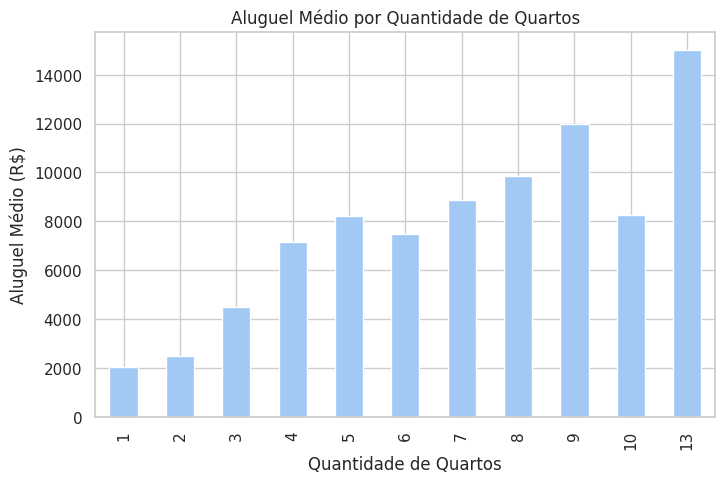

In [ ]:
plt.figure(figsize=(8,5))

df_clean.groupby('rooms')['rent amount (R$)'].mean().plot(kind='bar')

plt.title('Aluguel Médio por Quantidade de Quartos')
plt.xlabel('Quantidade de Quartos')
plt.ylabel('Aluguel Médio (R$)')

plt.show()

In [ ]:
df_clean[['rooms', 'rent amount (R$)']].corr()

,rooms,rent amount (R$)
rooms,1.0000,0.5364
rent amount (R$),0.5364,1.0000


### Insight

- Observou-se uma tendência de aumento do aluguel médio conforme cresce o número de quartos.

- A correlação moderada (0,54) indica que essa característica possui influência relevante na formação do preço dos imóveis.

<font color="#1565C0" size="4">
<b>8.4 Banheiros x Aluguel</b>
</font>


Nesta etapa será investigada a relação entre a quantidade de banheiros dos imóveis e seus respectivos valores de aluguel.

In [ ]:
df_clean.groupby('bathroom')['rent amount (R$)'].mean()

,rent amount (R$)
bathroom,
1,1873.188106
2,3390.508747
3,5442.573590
4,7186.007233
5,8367.635253
6,9156.613953
7,10370.047059
8,12842.000000
9,10092.250000


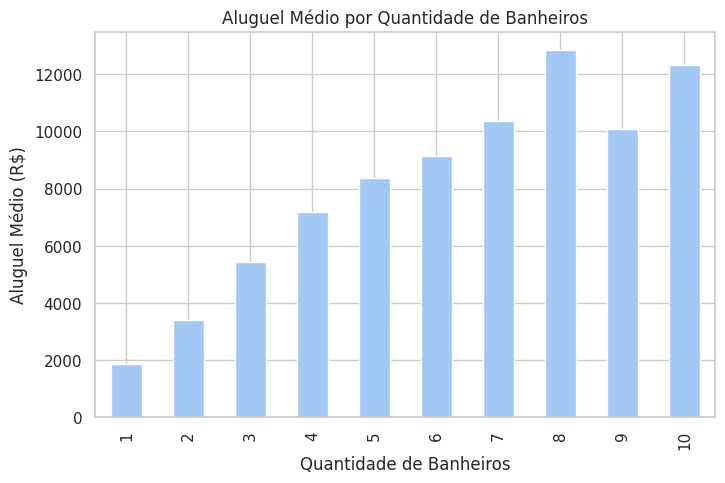

In [ ]:
plt.figure(figsize=(8,5))

df_clean.groupby('bathroom')['rent amount (R$)'].mean().plot(kind='bar')

plt.title('Aluguel Médio por Quantidade de Banheiros')
plt.xlabel('Quantidade de Banheiros')
plt.ylabel('Aluguel Médio (R$)')

plt.show()

In [ ]:
df_clean[['bathroom', 'rent amount (R$)']].corr()

,bathroom,rent amount (R$)
bathroom,1.000000,0.665678
rent amount (R$),0.665678,1.000000


### Insight

- A quantidade de banheiros apresentou a maior correlação observada até o momento (0,67).

- Esse resultado sugere que imóveis com mais banheiros tendem a pertencer a segmentos de maior padrão e, consequentemente, apresentam aluguéis mais elevados.

<font color="#1565C0" size="4">
<b>8.7 Mobília</b>
</font>

Nesta etapa será investigada a relação entre a quantidade de vagas de garagem e os valores de aluguel.

In [ ]:
df_clean.groupby('parking spaces')['rent amount (R$)'].mean()

,rent amount (R$)
parking spaces,
0,2187.937676
1,2625.614241
2,4539.341809
3,6437.618257
4,7738.373248
5,8324.480176
6,8867.846626
7,9486.363636
8,8704.325203


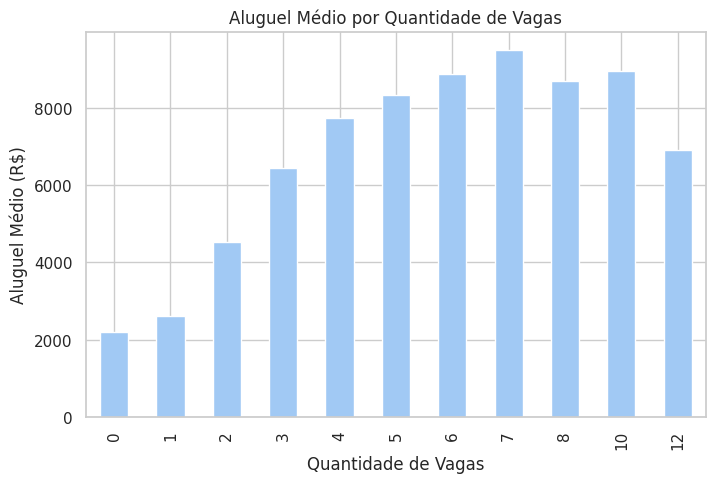

In [ ]:
plt.figure(figsize=(8,5))

df_clean.groupby('parking spaces')['rent amount (R$)'].mean().plot(kind='bar')

plt.title('Aluguel Médio por Quantidade de Vagas')
plt.xlabel('Quantidade de Vagas')
plt.ylabel('Aluguel Médio (R$)')

plt.show()

In [ ]:
df_clean[['parking spaces', 'rent amount (R$)']].corr()

,parking spaces,rent amount (R$)
parking spaces,1.00000,0.57395
rent amount (R$),0.57395,1.00000


### Insight

- O número de vagas de garagem apresentou correlação moderada com o valor do aluguel (0,57);

- Observa-se uma tendência geral de aumento do aluguel conforme cresce a quantidade de vagas, embora existam oscilações para quantidades mais elevadas.

<font color="#1565C0" size="4">
<b>8.6 Aceitação de Pets</b>
</font>

Nesta etapa será analisado se imóveis que aceitam animais apresentam diferenças nos valores de aluguel.

In [ ]:
df_clean.groupby('animal')['rent amount (R$)'].mean()

,rent amount (R$)
animal,
acept,4079.879802
not acept,3547.001772


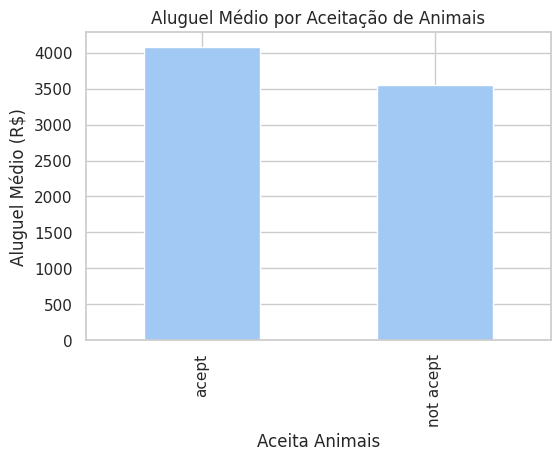

In [ ]:
plt.figure(figsize=(6,4))

df_clean.groupby('animal')['rent amount (R$)'].mean().plot(kind='bar')

plt.title('Aluguel Médio por Aceitação de Animais')
plt.xlabel('Aceita Animais')
plt.ylabel('Aluguel Médio (R$)')

plt.show()

### Insight

- Imóveis que aceitam animais apresentaram aluguel médio superior aos que não aceitam;

- A diferença observada sugere que a política de aceitação de animais pode estar associada a imóveis de padrão mais elevado ou mais flexíveis ao mercado.

<font color="#1565C0" size="4">
<b>8.7 Mobília</b>
</font>

Nesta etapa será analisado se imóveis mobiliados apresentam valores de aluguel superiores aos não mobiliados.

In [ ]:
df_clean.groupby('furniture')['rent amount (R$)'].mean()

,rent amount (R$)
furniture,
furnished,4970.715764
not furnished,3639.638516


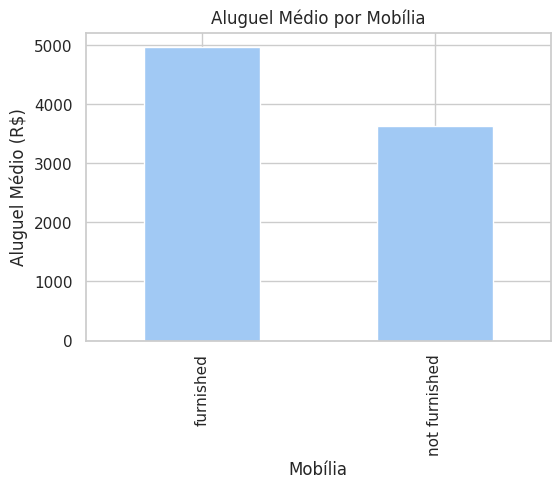

In [ ]:
plt.figure(figsize=(6,4))

df_clean.groupby('furniture')['rent amount (R$)'].mean().plot(kind='bar')

plt.title('Aluguel Médio por Mobília')
plt.xlabel('Mobília')
plt.ylabel('Aluguel Médio (R$)')

plt.show()

### Insight

- Imóveis mobiliados apresentaram maiores valores médios de aluguel;

- Esse resultado sugere que a presença de mobília é um fator relevante na precificação dos imóveis.

<font color="#1565C0" size="4">
<b>8.8 Principais Descobertas</b>
</font>

A análise exploratória permitiu identificar os principais fatores associados ao valor do aluguel.

Principais resultados:

- São Paulo apresentou os maiores valores médios de aluguel;
- A área do imóvel apresentou correlação moderada com o valor do aluguel (0,66);
- A quantidade de quartos apresentou correlação moderada (0,54);
- A quantidade de banheiros apresentou a maior correlação observada (0,67);
- O número de vagas de garagem também apresentou influência relevante (0,57);
- Imóveis que aceitam animais tendem a possuir aluguel médio superior;
- Imóveis mobiliados apresentaram os maiores valores médios de aluguel.

Esses resultados indicam os três fatores que mais influenciam  no preço do aluguel são: a área, a quantidade de banheiros e o número de vagas de garagem.

<font color="#1565C0" size="5">
<b>9. Correlação</b>
</font>

Nesta etapa será analisada a relação entre todas as variáveis numéricas da base de dados para identificar quais possuem maior associação com o valor do aluguel.

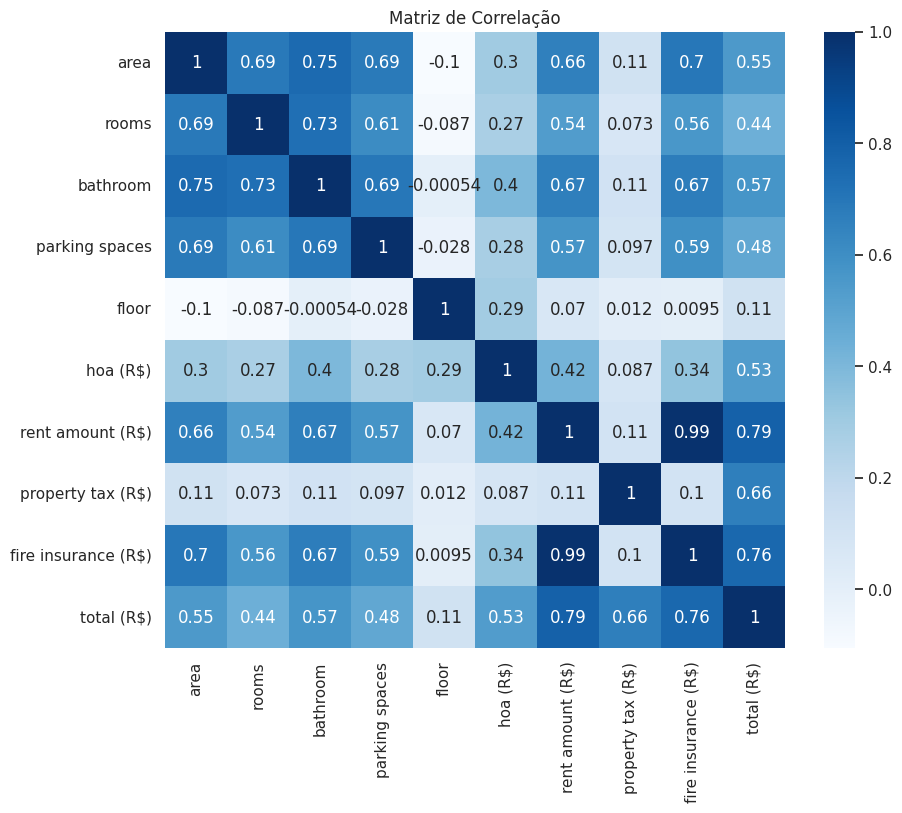

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title('Matriz de Correlação')
plt.show()

Text(0.5, 1.0, 'Relação entre Área e Valor do Aluguel')

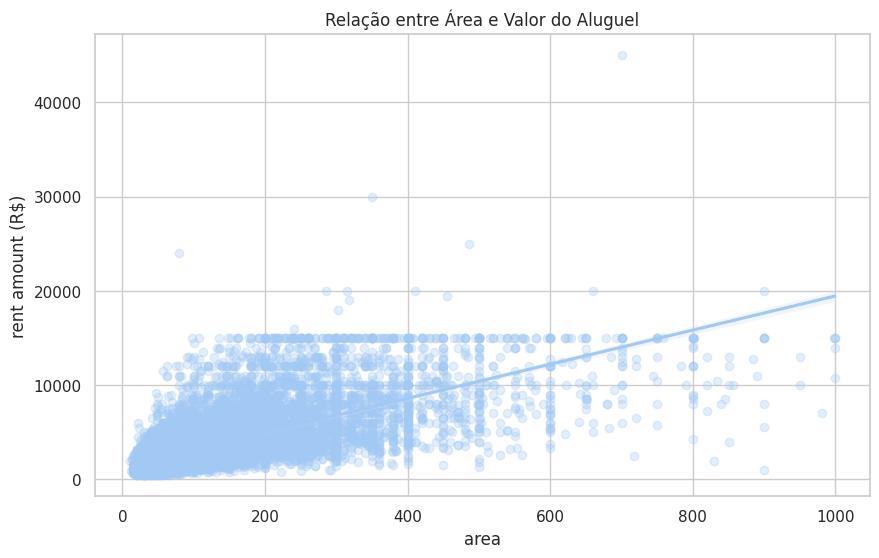

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_sem_outliers,
    x='area',
    y='rent amount (R$)',
    scatter_kws={'alpha':0.3}
)

plt.title('Relação entre Área e Valor do Aluguel')

<font color="#1565C0" size="5">
<b>10. Principais Descobertas</b>
</font>

- Imóveis maiores tendem a possuir aluguéis mais elevados;
- O número de banheiros possui forte influência no preço;
- Imóveis mobiliados apresentam valores superiores;
- Algumas cidades possuem aluguéis significativamente mais altos. área, reforçando a importância da etapa de limpeza e validação dos dados.

<font color="#1565C0" size="5">
<b>11. Conclusão</b>
</font>


### Respostas para as perguntas investigadas

- **A área do imóvel influencia o valor do aluguel?**
  - Sim. A área apresentou correlação de 0,66, sendo uma das variáveis mais relevantes para a precificação.

- **Existe relação entre quantidade de quartos e preço?**
  - Sim. Foi observada correlação moderada (0,54).

- **O número de banheiros impacta o aluguel?**
  - Sim. Foi a variável com maior correlação observada nesta análise (0,67), indicando forte associação com o valor do aluguel.

- **A quantidade de vagas influencia o valor do aluguel?**
  - Sim. A quantidade de vagas apresentou correlação moderada (0,57).

- **A aceitação de animais influencia o preço?**
  - Sim. Imóveis que aceitam animais apresentaram aluguel médio superior.

- **Imóveis mobiliados apresentam aluguéis mais elevados?**
  - Sim. Imóveis mobiliados registraram os maiores valores médios de aluguel.



<font color="#1565C0" size="5">
<b>12. Próximos Passos</b>
</font>

- Realizar tratamento mais aprofundado dos valores extremos e avaliar seus impactos no desempenho dos modelos;

- Construir modelos de regressão para previsão do valor dos aluguéis;

- Aplicar técnicas de validação e utilizar métricas como MAE, RMSE e R² para avaliação dos resultados.